# Libraries

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

In [67]:
df = pd.read_csv("data/pjm_noaa_merged.csv")

# Ensure DATE is datetime
df['DATE'] = pd.to_datetime(df['DATE'])

In [68]:
print(df.describe())

# Check missing values
print(df.isna().sum())

print(df.columns)

        Unnamed: 0          value                           DATE         AWND  \
count  5000.000000    5000.000000                           5003  5003.000000   
mean   2499.500000  116538.785800  2023-08-15 13:56:25.568658688     9.066962   
min       0.000000    3748.000000            2022-04-01 00:00:00     1.790000   
25%    1249.750000  101908.000000            2022-12-08 00:00:00     6.490000   
50%    2499.500000  110951.500000            2023-08-15 00:00:00     8.500000   
75%    3749.250000  125399.000000            2024-04-23 00:00:00    11.180000   
max    4999.000000  203751.000000            2024-12-31 00:00:00    22.590000   
std    1443.520003   22319.782566                            NaN     3.473966   

              PRCP         TAVG         TMAX         TMIN  
count  5003.000000  5003.000000  5003.000000  5003.000000  
mean      0.147529    60.082950    67.457525    47.521087  
min       0.000000    11.000000    18.000000     5.000000  
25%       0.000000    47.00000

Unnamed: 0     3
period         3
subba          3
subba-name     3
parent         3
parent-name    3
timezone       3
value          3
value-units    3
DATE           0
STATION        0
NAME           0
AWND           0
PRCP           0
TAVG           0
TMAX           0
TMIN           0
dtype: int64


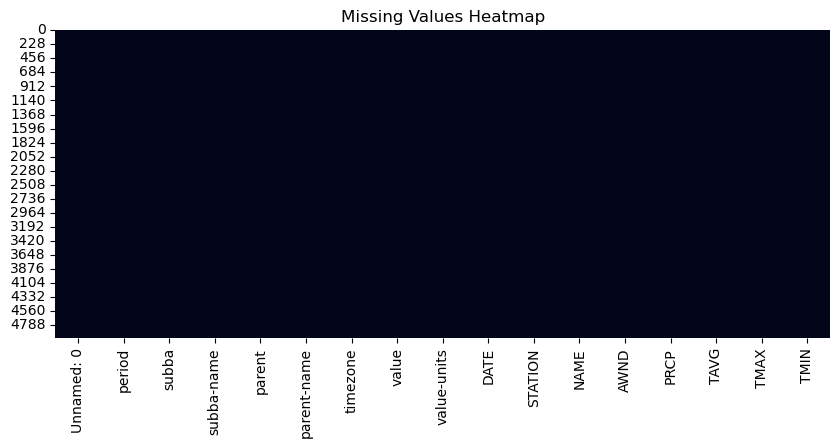

In [69]:
# Count missing values
print(df.isna().sum())

plt.figure(figsize=(10,4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

Rows with missing data: 3


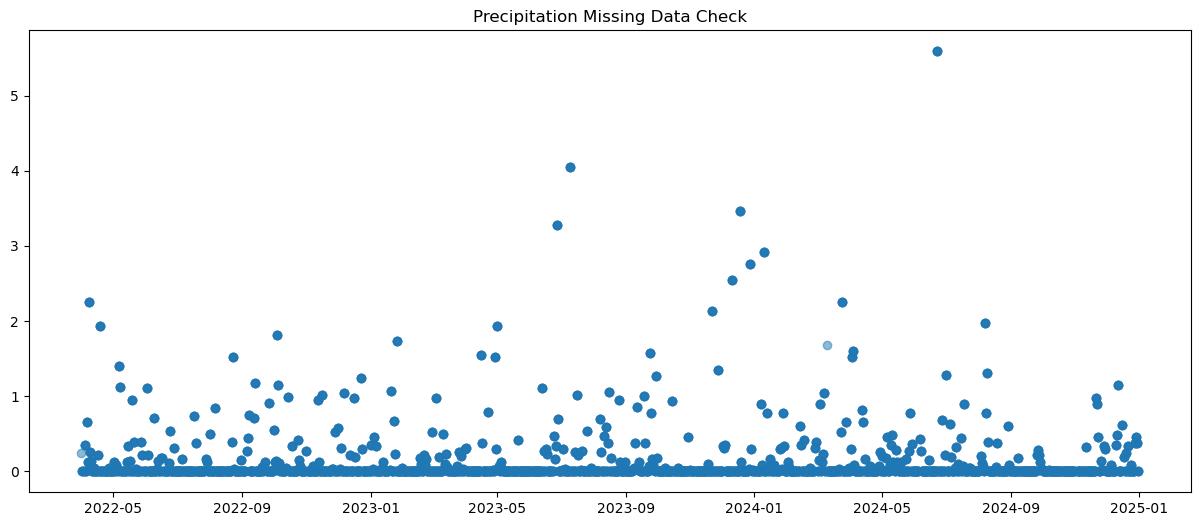

In [73]:
# Count missing values per column
df.isna().sum()

# Count missing rows
missing_rows = df[df.isna().any(axis=1)]
print("Rows with missing data:", len(missing_rows))

plt.figure(figsize=(15,6))
plt.plot(df['DATE'], df['PRCP'], marker='o', linestyle='', alpha=0.5)
plt.title("Precipitation Missing Data Check")
plt.show()

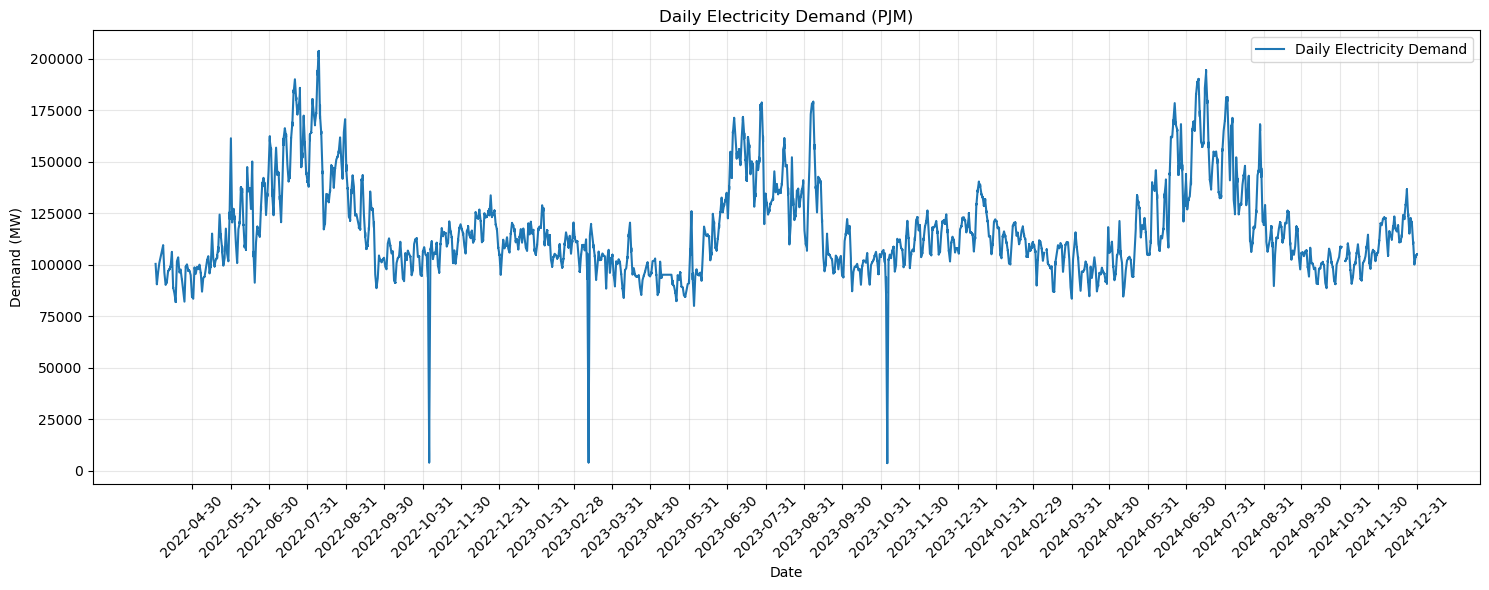

In [71]:
plt.figure(figsize=(15,6))
plt.plot(df['DATE'], df['value'], label='Daily Electricity Demand')

# Use month-end ticks ('ME') to reduce clutter
plt.xticks(
    pd.date_range(start=df['DATE'].min(), end=df['DATE'].max(), freq='ME'),
    rotation=45
)

plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.title('Daily Electricity Demand (PJM)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

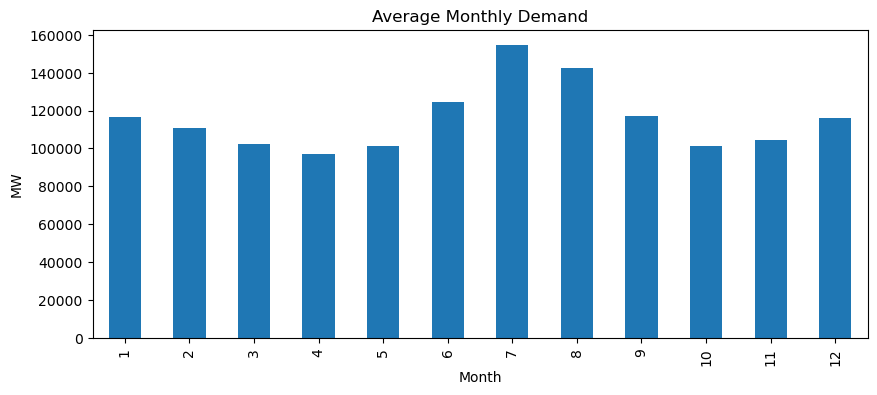

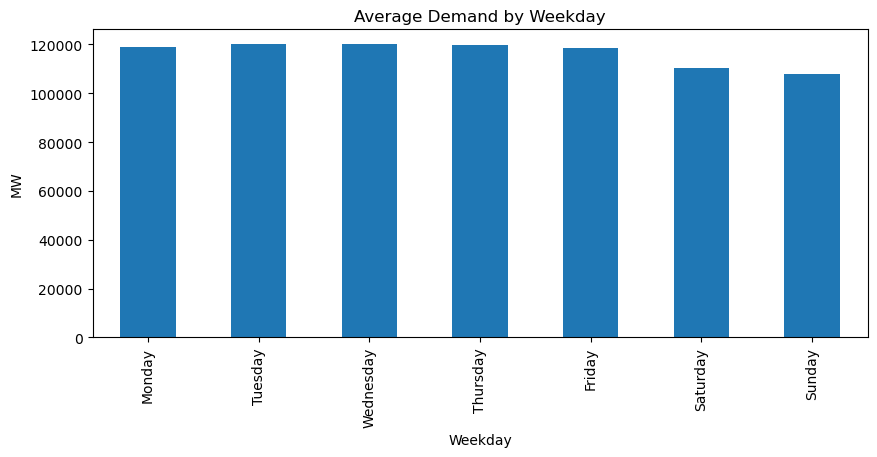

In [77]:
# Add Year, Month, Weekday columns
df['Year'] = df['DATE'].dt.year
df['Month'] = df['DATE'].dt.month
df['Weekday'] = df['DATE'].dt.day_name()

# Monthly 
monthly = df.groupby('Month')['value'].mean()
monthly.plot(kind='bar', figsize=(10,4), title="Average Monthly Demand")
plt.ylabel("MW")
plt.show()

# Weekly 
weekday = df.groupby('Weekday')['value'].mean()
weekday = weekday.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
weekday.plot(kind='bar', figsize=(10,4), title="Average Demand by Weekday")
plt.ylabel("MW")
plt.show()